## Section 1: Environment Setup and Data Loading
This section installs the required libraries and loads the UCI Heart Disease dataset (fedesoriano, 2021) into a pandas DataFrame. The dataset file heart.csv should be uploaded to the session before running. Fixed random seeds are used throughout to ensure reproducibility.

In [1]:
# Install required libraries
!pip install fairlearn -q
!pip install imbalanced-learn -q

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

# Load dataset
# heart.csv must be uploaded to the Colab session before running.
df = pd.read_csv('heart.csv')
print("Data loaded successfully:", df.shape)

Data loaded successfully: (918, 12)


## Section 2: Data Inspection

This section examines the structure and distribution of the raw dataset prior to any preprocessing. Key checks include data types, missing values, and the distribution of sensitive attributes (sex and age) which are central to the fairness analysis conducted in Section 6. Zero values in Cholesterol and RestingBP are identified as medically impossible and are therefore treated as missing values in the following section.


In [25]:

# Basic structure check
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

# Flag implausible zero values
print("\nZero Cholesterol:", (df['Cholesterol'] == 0).sum())
print("Zero RestingBP:", (df['RestingBP'] == 0).sum())

# Sensitive attribute distributions
print("\nSex distribution:\n", df['Sex'].value_counts())
print("\nHeartDisease distribution:\n", df['HeartDisease'].value_counts())
print("\nAge range:", df['Age'].min(), "to", df['Age'].max())

# Preview first five rows
df.head()


Shape: (918, 19)

Data types:
Age                     int64
Sex                     int64
RestingBP             float64
Cholesterol           float64
FastingBS               int64
MaxHR                   int64
ExerciseAngina          int64
Oldpeak               float64
HeartDisease            int64
AgeGroup             category
Sex_original           object
AgeGroup_original    category
ChestPainType_ATA       int64
ChestPainType_NAP       int64
ChestPainType_TA        int64
RestingECG_Normal       int64
RestingECG_ST           int64
ST_Slope_Flat           int64
ST_Slope_Up             int64
dtype: object

Missing values:
Age                    0
Sex                    0
RestingBP              1
Cholesterol          172
FastingBS              0
MaxHR                  0
ExerciseAngina         0
Oldpeak                0
HeartDisease           0
AgeGroup               0
Sex_original           0
AgeGroup_original      0
ChestPainType_ATA      0
ChestPainType_NAP      0
ChestPainType_TA   

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,AgeGroup,Sex_original,AgeGroup_original,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140.0,289.0,0,172,0,0.0,0,Under 45,M,Under 45,1,0,0,1,0,0,1
1,49,0,160.0,180.0,0,156,0,1.0,1,45-60,F,45-60,0,1,0,1,0,1,0
2,37,1,130.0,283.0,0,98,0,0.0,0,Under 45,M,Under 45,1,0,0,0,1,0,1
3,48,0,138.0,214.0,0,108,1,1.5,1,45-60,F,45-60,0,0,0,1,0,1,0
4,54,1,150.0,195.0,0,122,0,0.0,0,45-60,M,45-60,0,1,0,1,0,0,1


## Section 3: Data Cleaning and Feature Engineering

This section addresses the data quality issues identified in Section 2. Zero values in Cholesterol (172 cases, 18.7%) are biologically implausible and treated as missing. Imputation is performed using the median per sex group rather than a global median, as cholesterol distributions differ clinically between male and female patients. One zero RestingBP value is replaced with the overall median. Finally, Age is binned into three clinically meaningful groups — Under 45, 45–60, and Over 60 — to support group-level fairness analysis in Section 6. These cut points were selected to reflect recognised life stages in cardiovascular disease risk: under 45 represents patients relatively young for CHD, 45–60 captures the primary risk window, and over 60 reflects the age at which prevalence rises sharply (BHF, 2021a).

In [ ]:
# ── Section 3: Cleaning and feature engineering ──

# Zero cholesterol is biologically implausible - mark as missing
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

# Single zero RestingBP - mark as missing
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)

# Bin Age into three clinically relevant groups for fairness analysis
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[0, 45, 60, 100],
                        labels=['Under 45', '45-60', 'Over 60'])

# Retain original labels for sensitive attributes before encoding
df['Sex_original'] = df['Sex']
df['AgeGroup_original'] = df['AgeGroup']

print("Missing Cholesterol:", df['Cholesterol'].isna().sum())
print("Missing RestingBP:", df['RestingBP'].isna().sum())
print("\nAge group distribution:\n", df['AgeGroup'].value_counts())

Missing Cholesterol: 172
Missing RestingBP: 1

Age group distribution:
 AgeGroup
45-60       501
Over 60     221
Under 45    196
Name: count, dtype: int64


## Section 4: Feature Encoding

Categorical variables are converted to numerical representations using scikit-learn's LabelEncoder, as the logistic regression classifier requires numerical input. The following features are encoded: Sex, ChestPainType, RestingECG, ExerciseAngina, and ST_Slope. For sensitive attributes like Sex and AgeGroup, original string labels are retained as separate columns to support group-level fairness analysis in Section 6 and ensure interpretability in dashboard outputs.

In [ ]:
# ── Section 4: Encoding ──
# Binary features: label encode (no false ordering with two levels)
# Nominal features: one-hot encode - label encoding would impose a
# spurious ordinal relationship that logistic regression reads as magnitude

binary_cols = ['Sex', 'ExerciseAngina']
nominal_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']

encoders = {}
for col in binary_cols:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])
    print(f"{col}: {dict(zip(encoders[col].classes_, encoders[col].transform(encoders[col].classes_)))}")

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

print("\nEncoded shape:", df.shape)
print("Columns:", list(df.columns))

Sex: {'F': np.int64(0), 'M': np.int64(1)}
ExerciseAngina: {'N': np.int64(0), 'Y': np.int64(1)}

Encoded shape: (918, 19)
Columns: ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'AgeGroup', 'Sex_original', 'AgeGroup_original', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


## Section 5: Baseline Model Training and Evaluation

A logistic regression classifier is trained as the baseline model against, which fairness interventions are later evaluated. Logistic regression was selected for its interpretability and widespread use in clinical machine learning research, which supports the ethicality and correctability criteria of the procedural fairness protocol (Leventhal, 1980).

The dataset is split 80/20 into training and test sets using a fixed random seed (random_state=42) to ensure reproducibility. Sex and Age are retained as model features, as excluding them would not prevent the model from inferring them from correlated clinical variables — an approach known as fairness through unawareness, which is widely recognised as ineffective (Dwork et al., 2012). The original string labels for Sex and AgeGroup are preserved separately to enable group-level fairness evaluation in Section 6 and interpretable dashboard outputs. Note that AgeGroup is excluded from the feature matrix to avoid duplicating the continuous Age variable. Overall accuracy, AUC-ROC, precision, recall, and F1-score are reported.Recall for the positive class (heart disease present) is prioritised as the key clinical metric, as false negatives carry greater patient safety risk than false positives. This prioritisation may increase false positives and could lead to unnecessary follow-up investigations, but this tradeoff is clinically acceptable given the consequences of missed diagnoses (Simon and Aliferis, 2024).

In [7]:
# ── Section 5: Split, impute, scale, train ──
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import confusion_matrix


class SexGroupMedianImputer(BaseEstimator, TransformerMixin):
    """Impute missing values with the median within each sex group.

    Medians are learned from training data only (fit), then applied to
    unseen data (transform), so no test-set information leaks into
    preprocessing. Sex is expected as an encoded column in X.
    """
    def __init__(self, columns, sex_col='Sex'):
        self.columns = columns
        self.sex_col = sex_col

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.medians_ = {
            col: X.groupby(self.sex_col)[col].median().to_dict()
            for col in self.columns
        }
        self.global_medians_ = {col: X[col].median() for col in self.columns}
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.columns:
            fill = X[self.sex_col].map(self.medians_[col])
            fill = fill.fillna(self.global_medians_[col])
            X[col] = X[col].fillna(fill)
        return X


def group_metrics(y_true, y_pred, mask):
    """Accuracy, recall and n for a subgroup."""
    yt = np.asarray(y_true)[np.asarray(mask)]
    yp = np.asarray(y_pred)[np.asarray(mask)]
    pos = (yt == 1).sum()
    recall = ((yp == 1) & (yt == 1)).sum() / pos if pos else float('nan')
    return accuracy_score(yt, yp), recall, np.asarray(mask).sum()


X = df.drop(columns=['HeartDisease', 'AgeGroup', 'Sex_original', 'AgeGroup_original'])
y = df['HeartDisease']

sensitive_sex = df['Sex_original']
sensitive_age = df['AgeGroup_original']

# Stratify on outcome and sex jointly so the female test count is not left to chance
strata = df['HeartDisease'].astype(str) + "_" + df['Sex_original'].astype(str)

X_train, X_test, y_train, y_test, sex_train, sex_test, age_train, age_test = train_test_split(
    X, y, sensitive_sex, sensitive_age,
    test_size=0.2,
    random_state=42,
    stratify=strata
)

# Impute and scale inside a Pipeline so both are fitted on training data only,
# preventing test-set information from leaking into preprocessing
model = Pipeline([
    ('impute', SexGroupMedianImputer(columns=['Cholesterol', 'RestingBP'])),
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("BASELINE MODEL PERFORMANCE")
print(f"AUC-ROC          : {roc_auc_score(y_test, y_prob):.3f}")
print(f"Overall Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix (rows=actual, cols=predicted):")
print(confusion_matrix(y_test, y_pred))
print(f"\nTest set composition: {(sex_test=='M').sum()} male, {(sex_test=='F').sum()} female")

print("\nImputation medians (learned on training data):")
for col, medians in model.named_steps['impute'].medians_.items():
    print(f"  {col}: {medians}")

BASELINE MODEL PERFORMANCE
AUC-ROC          : 0.957
Overall Accuracy : 0.891

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

Confusion matrix (rows=actual, cols=predicted):
[[71 11]
 [ 9 93]]

Test set composition: 145 male, 39 female

Imputation medians (learned on training data):
  Cholesterol: {0: 248.0, 1: 237.0}
  RestingBP: {0: 130.0, 1: 130.0}


## Section 6: Leventhal Fairness Assessment — Baseline Model

This section evaluates the baseline logistic regression model against all six of Leventhal's (1980) procedural justice rules. Following the sociotechnical perspective proposed by Selbst et al. (2019), the criteria are divided into two categories:

**Technical criteria** — assessed computationally using quantitative thresholds:
- Accuracy (6.1)
- Bias Suppression (6.2)
- Representativeness (6.3)
- Consistency (6.4)

**Sociotechnical criteria** — assessed qualitatively using structured checklists, as these cannot be fully captured through pipeline metrics alone:
- Correctability (6.5)
- Ethicality (6.6)

A summary of all six assessments is presented in Section 6.7. The same assessment framework is repeated on the mitigated model in Section 8 to enable direct comparison.

### Section 6.1: Accuracy

Leventhal's accuracy rule requires that decisions are based on accurate information processed with minimum error (Leventhal, 1980). This is assessed using AUC-ROC on the held-out test set, with a minimum threshold of 0.80. Values above this level are conventionally interpreted as indicating good discrimination between two outcomes (Mandrekar, 2010). AUC-ROC is used as the pass criterion in preference to overall accuracy because it reflects the model's ability to rank patients by risk independently of the classification threshold, and is less sensitive to class imbalance. Overall accuracy, precision, recall and F1-score are reported alongside as context. Note that aggregate performance alone is insufficient for fairness evaluation, and group-level disparities are examined in Section 6.2.

In [28]:
# Compute overall accuracy and AUC-ROC
overall_accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("LEVENTHAL RULE 1: ACCURACY")
print(f"Overall Accuracy : {overall_accuracy:.3f}")
print(f"AUC-ROC          : {auc:.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

threshold = 0.80
print()
if auc >= threshold:
    print(f"PASS — AUC-ROC ({auc:.3f}) meets the 0.80 threshold.")
    print(f"       Overall accuracy ({overall_accuracy:.1%}) reported as context.")
else:
    print(f"FAIL — AUC-ROC ({auc:.3f}) falls below the 0.80 threshold.")

LEVENTHAL RULE 1: ACCURACY
Overall Accuracy : 0.891
AUC-ROC          : 0.957

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184


PASS — AUC-ROC (0.957) meets the 0.80 threshold.
       Overall accuracy (89.1%) reported as context.


### Section 6.2: Bias Suppression

Leventhal's bias suppression rule requires that protected attributes do not unduly influence decisions (Leventhal, 1980). This is assessed by disaggregating model performance by sex and age group, and computing two formal fairness metrics using Fairlearn: demographic parity difference (the gap in positive prediction rates across groups) and equalised odds difference (the gap in true positive and false positive rates across groups). An acceptable disparity threshold of ±0.10 is applied, following standard practice in algorithmic fairness literature. A score of 0 on either metric indicates perfect fairness; higher values indicate greater disparity.

In [29]:
print("LEVENTHAL RULE 2: BIAS SUPPRESSION")

# Group level performance by sex
print("\nPerformance by Sex:")
for group in ['M', 'F']:
    acc, recall, n = group_metrics(y_test, y_pred, sex_test == group)
    print(f"  {group} | Accuracy: {acc:.3f} | Recall: {recall:.3f} | n={n}")

# Group level performance by age group
print("\nPerformance by Age Group:")
for group in ['Under 45', '45-60', 'Over 60']:
    acc, recall, n = group_metrics(y_test, y_pred, age_test == group)
    print(f"  {group} | Accuracy: {acc:.3f} | Recall: {recall:.3f} | n={n}")

# Formal fairness metrics
print("\nFormal Fairness Metrics (Sex):")
dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=sex_test)
eo_diff = equalized_odds_difference(y_test, y_pred, sensitive_features=sex_test)
print(f"  Demographic Parity Difference : {dp_diff:.3f}")
print(f"  Equalised Odds Difference     : {eo_diff:.3f}")

# Pass/fail against ±0.10 threshold
threshold = 0.10
print()
if abs(dp_diff) <= threshold and abs(eo_diff) <= threshold:
    print("PASS — Bias suppression within acceptable threshold (±0.10).")
else:
    print("FAIL — Bias suppression exceeds acceptable threshold (±0.10).")
    print(f"  Demographic Parity Difference: {dp_diff:.3f}")
    print(f"  Equalised Odds Difference: {eo_diff:.3f}")

LEVENTHAL RULE 2: BIAS SUPPRESSION

Performance by Sex:
  M | Accuracy: 0.890 | Recall: 0.935 | n=145
  F | Accuracy: 0.897 | Recall: 0.700 | n=39

Performance by Age Group:
  Under 45 | Accuracy: 0.946 | Recall: 0.857 | n=37
  45-60 | Accuracy: 0.873 | Recall: 0.906 | n=102
  Over 60 | Accuracy: 0.889 | Recall: 0.943 | n=45

Formal Fairness Metrics (Sex):
  Demographic Parity Difference : 0.457
  Equalised Odds Difference     : 0.235

FAIL — Bias suppression exceeds acceptable threshold (±0.10).
  Demographic Parity Difference: 0.457
  Equalised Odds Difference: 0.235


### Section 6.3: Representativeness

A representation ratio is calculated by dividing the dataset's female proportion by the reference female proportion from BHF (2021a) inpatient admissions data for England 2019/20. A threshold of 0.80 is applied, adapted from the four-fifths rule set out in the EEOC Uniform Guidelines on Employee Selection Procedures (1978), under which a group represented at less than 80% of a reference rate is considered adversely affected. This threshold originates in employment law rather than clinical research, and its transfer to dataset composition is an assumption of this study rather than an established standard.

In [30]:
print("LEVENTHAL RULE 3: REPRESENTATIVENESS")
print()

# Dataset demographic breakdown
total = len(df)
female_count = (df['Sex_original'] == 'F').sum()
male_count = (df['Sex_original'] == 'M').sum()
dataset_female_pct = female_count / total
dataset_male_pct = male_count / total

print("Dataset Demographics:")
print(f"  Male   : {male_count} ({dataset_male_pct:.1%})")
print(f"  Female : {female_count} ({dataset_female_pct:.1%})")

# Age group breakdown
print()
print("Age Group Distribution:")
for group in ['Under 45', '45-60', 'Over 60']:
    count = (df['AgeGroup_original'] == group).sum()
    pct = count / total
    print(f"  {group} : {count} ({pct:.1%})")

# Sex representativeness — BHF (2021a) reference: 33% female CHD inpatients England 2019/20
reference_female_pct = 0.33
representation_ratio_sex = dataset_female_pct / reference_female_pct

print()
print("Representativeness Assessment (Sex):")
print(f"  Dataset female prevalence   : {dataset_female_pct:.1%}")
print(f"  Reference female prevalence : {reference_female_pct:.1%} (BHF, 2021a)")
print(f"  Representation ratio        : {representation_ratio_sex:.2f}")

threshold = 0.80
print()
if representation_ratio_sex >= threshold:
    print(f"PASS — Female representation ratio ({representation_ratio_sex:.2f}) meets threshold (0.80).")
else:
    print(f"FAIL — Female representation ratio ({representation_ratio_sex:.2f}) falls below threshold (0.80).")
    print("  Female patients are underrepresented relative to real-world CHD prevalence.")

# Age representativeness — directional comparison only
# BHF (2021b) figures reflect prevalence rates within age groups not proportions of total cases
age_reference = {
    'Under 45': 0.009,
    '45-60': 0.075,
    'Over 60': 0.270
}

print()
print("Representativeness Assessment (Age Groups — Directional):")
print("Reference: CHD prevalence rates within age groups, England 2017 (BHF, 2021b)")
print()
for group in ['Under 45', '45-60', 'Over 60']:
    count = (df['AgeGroup_original'] == group).sum()
    dataset_pct = count / total
    ref_pct = age_reference[group]
    print(f"  {group} | Dataset: {dataset_pct:.1%} | Reference prevalence: {ref_pct:.1%}")

# Calculate under-60 percentage dynamically
under_45_pct = (df['AgeGroup_original'] == 'Under 45').sum() / total
pct_45_60 = (df['AgeGroup_original'] == '45-60').sum() / total
under_60_pct = under_45_pct + pct_45_60

print()
print("Interpretation:")
print("  CHD prevalence rises sharply with age (0.9% under 45 vs 27.0% over 60).")
print(f"  Yet {under_60_pct:.1%} of dataset patients are under 60, suggesting younger patients")
print("  are overrepresented relative to real-world CHD burden.")
print("  FAIL — dataset age distribution does not reflect real-world CHD prevalence pattern.")

LEVENTHAL RULE 3: REPRESENTATIVENESS

Dataset Demographics:
  Male   : 725 (79.0%)
  Female : 193 (21.0%)

Age Group Distribution:
  Under 45 : 196 (21.4%)
  45-60 : 501 (54.6%)
  Over 60 : 221 (24.1%)

Representativeness Assessment (Sex):
  Dataset female prevalence   : 21.0%
  Reference female prevalence : 33.0% (BHF, 2021a)
  Representation ratio        : 0.64

FAIL — Female representation ratio (0.64) falls below threshold (0.80).
  Female patients are underrepresented relative to real-world CHD prevalence.

Representativeness Assessment (Age Groups — Directional):
Reference: CHD prevalence rates within age groups, England 2017 (BHF, 2021b)

  Under 45 | Dataset: 21.4% | Reference prevalence: 0.9%
  45-60 | Dataset: 54.6% | Reference prevalence: 7.5%
  Over 60 | Dataset: 24.1% | Reference prevalence: 27.0%

Interpretation:
  CHD prevalence rises sharply with age (0.9% under 45 vs 27.0% over 60).
  Yet 75.9% of dataset patients are under 60, suggesting younger patients
  are overrep

### Section 6.3 (cont.): Representativeness Visualisation

Figure 1 illustrates the disparity between dataset demographics and real-world CHD prevalence. The sex chart compares dataset composition against BHF (2021a) inpatient admissions data. The age chart compares dataset age group distribution against BHF (2021b) prevalence rates, shown directionally.

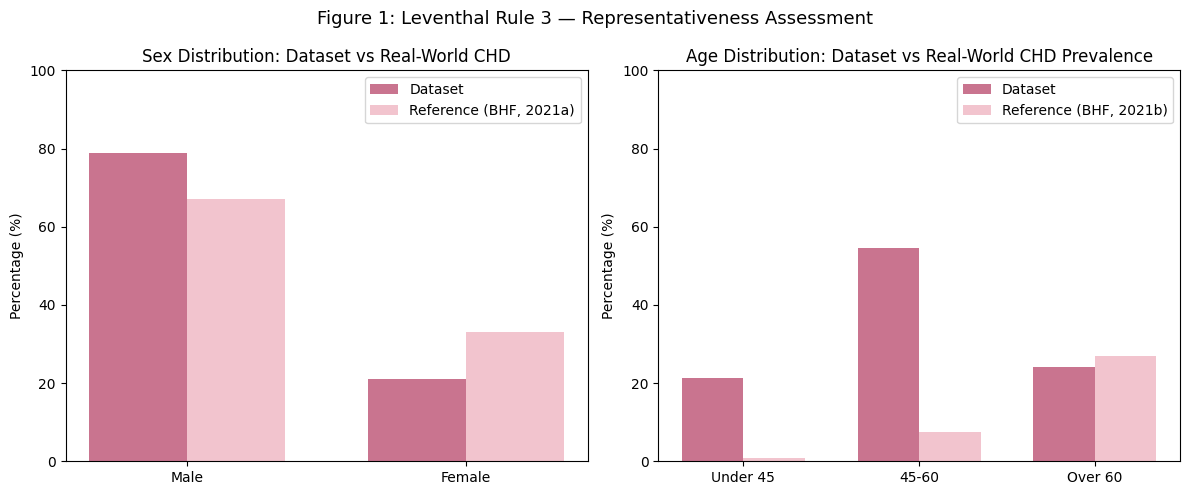

Figure 1 saved as representativeness_chart.png


In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sex_labels = ['Male', 'Female']
dataset_sex = [dataset_male_pct * 100, dataset_female_pct * 100]
reference_sex = [67, 33]
x = np.arange(len(sex_labels))
width = 0.35

ax1.bar(x - width/2, dataset_sex, width, label='Dataset', color='#c9748f')
ax1.bar(x + width/2, reference_sex, width, label='Reference (BHF, 2021a)', color='#f2c4ce')
ax1.set_title('Sex Distribution: Dataset vs Real-World CHD')
ax1.set_ylabel('Percentage (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(sex_labels)
ax1.legend()
ax1.set_ylim(0, 100)

age_labels = ['Under 45', '45-60', 'Over 60']
dataset_age = [(df['AgeGroup_original'] == g).sum() / total * 100 for g in age_labels]
reference_age = [age_reference[g] * 100 for g in age_labels]

ax2.bar(x2 - width/2, dataset_age, width, label='Dataset', color='#c9748f')
ax2.bar(x2 + width/2, reference_age, width, label='Reference (BHF, 2021b)', color='#f2c4ce')
ax2.set_title('Age Distribution: Dataset vs Real-World CHD Prevalence')
ax2.set_ylabel('Percentage (%)')
ax2.set_xticks(x2)
ax2.set_xticklabels(age_labels)
ax2.legend()
ax2.set_ylim(0, 100)

plt.suptitle('Figure 1: Leventhal Rule 3 — Representativeness Assessment', fontsize=13)
plt.tight_layout()
plt.savefig('representativeness_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 1 saved as representativeness_chart.png")

### Section 6.4: Consistency

Leventhal's consistency rule requires that the same decision logic produces stable, predictable outputs across people and over time (Leventhal, 1980). This is assessed using a prediction stability test: clinically realistic Gaussian noise of ±1 unit is added to continuous features in the test set — representing minor measurement variation such as ±1 mmHg blood pressure or ±1 year of age — and the proportion of predictions that change is recorded as the instability rate. A maximum instability threshold of 5% is applied.

Noise is applied only to continuous features (Age, RestingBP, Cholesterol, FastingBS, MaxHR, Oldpeak). Binary encoded categorical features are excluded as perturbing them would be clinically meaningless and could artificially inflate the instability rate. A fixed random seed ensures reproducibility.

In [ ]:
print("LEVENTHAL RULE 4: CONSISTENCY")
print()

np.random.seed(42)

# Add ±1 unit noise to continuous features only
noise_scale = 1.0
continuous_features = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

X_test_noisy = X_test.copy()
for col in continuous_features:
    if col in X_test_noisy.columns:
        noise = np.random.normal(0, noise_scale, X_test_noisy[col].shape)
        X_test_noisy[col] = X_test_noisy[col] + noise

# Compare predictions on original vs noisy test set
y_pred_original = model.predict(X_test)
y_pred_noisy = model.predict(X_test_noisy)

changed_predictions = (y_pred_original != y_pred_noisy).sum()
instability_rate = changed_predictions / len(y_pred_original)

print(f"Total test cases        : {len(y_pred_original)}")
print(f"Changed predictions     : {changed_predictions}")
print(f"Instability rate        : {instability_rate:.1%}")

# Pass/fail against 5% threshold
threshold = 0.05
print()
if instability_rate <= threshold:
    print(f"PASS — Instability rate ({instability_rate:.1%}) within acceptable threshold (5%).")
else:
    print(f"FAIL — Instability rate ({instability_rate:.1%}) exceeds acceptable threshold (5%).")

# Group level breakdown
print()
print("Consistency by Sex:")
for group in ['M', 'F']:
    mask = np.asarray(sex_test == group)
    changed = (y_pred_original[mask] != y_pred_noisy[mask]).sum()
    rate = changed / mask.sum()
    print(f"  {group} | Changed: {changed} / {mask.sum()} | Instability rate: {rate:.1%}")

print()
print("Consistency by Age Group:")
for group in ['Under 45', '45-60', 'Over 60']:
    mask = np.asarray(age_test == group)
    changed = (y_pred_original[mask] != y_pred_noisy[mask]).sum()
    rate = changed / mask.sum()
    print(f"  {group} | Changed: {changed} / {mask.sum()} | Instability rate: {rate:.1%}")

### Section 6.5: Correctability

Leventhal's correctability rule requires that mechanisms exist to allow flawed decisions to be reviewed, challenged, and corrected (Leventhal, 1980). This criterion cannot be assessed computationally — it requires institutional and system-level design beyond the scope of a machine learning pipeline. It is therefore assessed qualitatively using a structured checklist covering prediction interpretability, override mechanisms, audit trails, and stakeholder communication. A pass threshold of 80% of criteria met is applied.

In [33]:
# Checklist developed for this study. No validated instrument exists for assessing
# Leventhal's rules in healthcare ML. The approach of operationalising governance
# principles as structured assessment questions follows ALTAI (EU HLEG, 2020);
# individual items are informed by ICO/Alan Turing Institute guidance on explaining
# AI decisions (2020), UK GDPR provisions on automated decision-making, and
# institutional research ethics requirements.

print("LEVENTHAL RULE 5: CORRECTABILITY")
print()

correctability_checklist = {
    "Prediction outputs are visible and interpretable"   : True,
    "Confidence scores are provided with predictions"    : True,
    "Clinician override mechanism exists"                : False,
    "Patient challenge mechanism exists"                 : False,
    "Audit trail of predictions is maintained"           : False,
    "Model version history is recorded"                  : False,
    "Dashboard communicates uncertainty to stakeholders" : True,
}

print("Correctability Checklist:")
print()
for criterion, status in correctability_checklist.items():
    result = "PASS" if status else "FAIL"
    print(f"  [{result}] {criterion}")

passed = sum(correctability_checklist.values())
total_checks = len(correctability_checklist)

print()
print(f"Criteria met: {passed} / {total_checks}")
print()
if passed / total_checks >= 0.8:
    print("PASS — Correctability criteria sufficiently met.")
else:
    print("FAIL — Correctability criteria not sufficiently met.")
    print("  The pipeline lacks clinician override and audit trail mechanisms.")
    print("  The dashboard partially addresses this through transparent")
    print("  communication of predictions and uncertainty to stakeholders.")
    print("  Full correctability requires institutional design beyond this project.")

LEVENTHAL RULE 5: CORRECTABILITY

Correctability Checklist:

  [PASS] Prediction outputs are visible and interpretable
  [PASS] Confidence scores are provided with predictions
  [FAIL] Clinician override mechanism exists
  [FAIL] Patient challenge mechanism exists
  [FAIL] Audit trail of predictions is maintained
  [FAIL] Model version history is recorded
  [PASS] Dashboard communicates uncertainty to stakeholders

Criteria met: 3 / 7

FAIL — Correctability criteria not sufficiently met.
  The pipeline lacks clinician override and audit trail mechanisms.
  The dashboard partially addresses this through transparent
  communication of predictions and uncertainty to stakeholders.
  Full correctability requires institutional design beyond this project.


### Section 6.6: Ethicality

Leventhal's ethicality rule requires that procedures accord with prevailing moral and ethical standards, respect patient dignity and rights, and avoid unjust harm (Leventhal, 1980). Like correctability, this criterion cannot be fully assessed computationally and is evaluated using a structured qualitative checklist. The checklist covers institutional ethics approval, data anonymisation, GDPR compliance, informed consent, and transparency of findings. A pass threshold of 80% of criteria met is applied.

One criterion — informed consent for ML research use — is marked as a known failure. The UCI Heart Disease dataset was collected from clinical settings as early as 1988, prior to modern AI ethics frameworks. Patients whose records form part of this dataset are unlikely to have provided explicit consent for use in machine learning research. This represents a retroactive ethical limitation that cannot be resolved within the scope of this project but is acknowledged in line with current research ethics standards.

In [34]:
# Checklist developed for this study. No validated instrument exists for assessing
# Leventhal's rules in healthcare ML. The approach of operationalising governance
# principles as structured assessment questions follows ALTAI (EU HLEG, 2020);
# individual items are informed by ICO/Alan Turing Institute guidance on explaining
# AI decisions (2020), UK GDPR provisions on automated decision-making, and
# institutional research ethics requirements.

print("LEVENTHAL RULE 6: ETHICALITY")
print()

ethicality_checklist = {
    "Ethics approval granted by Newcastle University"      : True,
    "Dataset is fully anonymised — no patient identifiers" : True,
    "No personal data collected or processed"              : True,
    "GDPR compliance — survey is anonymous"                : True,
    "Dataset used within its intended research purpose"    : True,
    "Patients gave informed consent for ML research use"   : False,
    "System designed to avoid unjust harm to patients"     : True,
    "Findings communicated transparently via dashboard"    : True,
}

print("Ethicality Checklist:")
print()
for criterion, status in ethicality_checklist.items():
    result = "PASS" if status else "FAIL"
    print(f"  [{result}] {criterion}")

passed = sum(ethicality_checklist.values())
total_checks = len(ethicality_checklist)

print()
print(f"Criteria met: {passed} / {total_checks}")
print()
if passed / total_checks >= 0.8:
    print("PASS — Ethicality criteria sufficiently met.")
    print("  Note: Informed consent for ML research use is marked as a known")
    print("  limitation. The dataset predates modern AI ethics frameworks and")
    print("  this cannot be resolved retroactively within this project.")
else:
    print("FAIL — Ethicality criteria not sufficiently met.")

LEVENTHAL RULE 6: ETHICALITY

Ethicality Checklist:

  [PASS] Ethics approval granted by Newcastle University
  [PASS] Dataset is fully anonymised — no patient identifiers
  [PASS] No personal data collected or processed
  [PASS] GDPR compliance — survey is anonymous
  [PASS] Dataset used within its intended research purpose
  [FAIL] Patients gave informed consent for ML research use
  [PASS] System designed to avoid unjust harm to patients
  [PASS] Findings communicated transparently via dashboard

Criteria met: 7 / 8

PASS — Ethicality criteria sufficiently met.
  Note: Informed consent for ML research use is marked as a known
  limitation. The dataset predates modern AI ethics frameworks and
  this cannot be resolved retroactively within this project.


### Section 6.7: Baseline Assessment Summary

This section summarises the results of all six Leventhal rule assessments for the baseline model. Four of the six criteria fail, indicating significant procedural fairness issues in the unmitigated pipeline. Section 7 applies bias suppression mitigation to address the most technically tractable failure. Representativeness and consistency require data collection solutions beyond the scope of this project. Correctability and ethicality require institutional interventions and remain unchanged following mitigation.

In [35]:
print("BASELINE LEVENTHAL ASSESSMENT SUMMARY")
print()

baseline_results = {
    "Accuracy"          : "PASS",
    "Bias Suppression"  : "FAIL",
    "Representativeness": "FAIL",
    "Consistency"       : "FAIL",
    "Correctability"    : "FAIL",
    "Ethicality"        : "PASS",
}

print(f"{'Rule':<20} {'Result':<10} {'Assessment Type':<15}")
print("-" * 48)
assessment_type = {
    "Accuracy"          : "Technical",
    "Bias Suppression"  : "Technical",
    "Representativeness": "Technical",
    "Consistency"       : "Technical",
    "Correctability"    : "Sociotechnical",
    "Ethicality"        : "Sociotechnical",
}

for rule, result in baseline_results.items():
    print(f"{rule:<20} {result:<10} {assessment_type[rule]:<15}")

passes = sum(1 for r in baseline_results.values() if r == "PASS")
fails = sum(1 for r in baseline_results.values() if r == "FAIL")

print()
print(f"Total PASS : {passes} / 6")
print(f"Total FAIL : {fails} / 6")
print()
print("Bias suppression mitigation is applied in Section 7.")
print("Remaining failures are addressed as recommendations in the dissertation.")

BASELINE LEVENTHAL ASSESSMENT SUMMARY

Rule                 Result     Assessment Type
------------------------------------------------
Accuracy             PASS       Technical      
Bias Suppression     FAIL       Technical      
Representativeness   FAIL       Technical      
Consistency          FAIL       Technical      
Correctability       FAIL       Sociotechnical 
Ethicality           PASS       Sociotechnical 

Total PASS : 2 / 6
Total FAIL : 4 / 6

Bias suppression mitigation is applied in Section 7.
Remaining failures are addressed as recommendations in the dissertation.


## Section 7: Fairness Mitigation

Of the four baseline failures identified in Section 6.7, bias suppression is the most technically addressable. The remaining failures — representativeness, consistency, and correctability — require data collection improvements and institutional design respectively, and are addressed as recommendations in the dissertation discussion.

Fairlearn's ExponentiatedGradient algorithm is applied with an EqualizedOdds constraint, which requires equal true positive and false positive rates across sex groups. The algorithm iteratively reweights the training data to find the optimal balance between predictive accuracy and fairness. A constraint tolerance of eps=0.01 is applied to allow the optimiser to find a solution that satisfies the fairness constraint while maintaining overall accuracy above the 80% clinical threshold. Sex is used as the sensitive feature as it exhibited the most significant bias suppression failure in the baseline assessment.

In [45]:
print("SECTION 7: FAIRNESS MITIGATION")
print()

# Apply ExponentiatedGradient with EqualizedOdds constraint.
# The base estimator is the same Pipeline used for the baseline model, so
# imputation and scaling are identical and the comparison is like-for-like.
# eps=0.01 sets constraint tolerance, allowing the optimiser to balance
# fairness against predictive performance.
constraint = EqualizedOdds()

mitigated_model = ExponentiatedGradient(
    Pipeline([
        ('impute', SexGroupMedianImputer(columns=['Cholesterol', 'RestingBP'])),
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    constraints=constraint,
    eps=0.01,
    sample_weight_name='clf__sample_weight'
)
mitigated_model.fit(X_train, y_train, sensitive_features=sex_train)
y_pred_mitigated = mitigated_model.predict(X_test)


# Overall performance
print(f"Overall Accuracy : {accuracy_score(y_test, y_pred_mitigated):.3f}")
print()

print("Performance by Sex:")
for group in ['M', 'F']:
    acc, rec, n = group_metrics(y_test, y_pred_mitigated, sex_test == group)
    print(f"  {group} | Accuracy: {acc:.3f} | Recall: {rec:.3f} | n={n}")

print()

print("Performance by Age Group:")
for group in ['Under 45', '45-60', 'Over 60']:
    acc, rec, n = group_metrics(y_test, y_pred_mitigated, age_test == group)
    print(f"  {group} | Accuracy: {acc:.3f} | Recall: {rec:.3f} | n={n}")
print()

# Formal fairness metrics — baseline vs mitigated comparison
print("Fairness Metrics: Baseline vs Mitigated")
print()
dp_diff_mitigated = demographic_parity_difference(y_test, y_pred_mitigated, sensitive_features=sex_test)
eo_diff_mitigated = equalized_odds_difference(y_test, y_pred_mitigated, sensitive_features=sex_test)
print(f"  Demographic Parity Difference : Baseline {dp_diff:.3f} → Mitigated {dp_diff_mitigated:.3f}")
print(f"  Equalised Odds Difference     : Baseline {eo_diff:.3f} → Mitigated {eo_diff_mitigated:.3f}")

print()
threshold = 0.10
if abs(dp_diff_mitigated) <= threshold and abs(eo_diff_mitigated) <= threshold:
    print("PASS — Bias suppression within acceptable threshold (±0.10) after mitigation.")
else:
    print("FAIL — Bias suppression still exceeds acceptable threshold (±0.10) after mitigation.")
    print(f"  Demographic Parity Difference: {dp_diff_mitigated:.3f}")
    print(f"  Equalised Odds Difference: {eo_diff_mitigated:.3f}")

SECTION 7: FAIRNESS MITIGATION

Overall Accuracy : 0.880

Performance by Sex:
  M | Accuracy: 0.883 | Recall: 0.924 | n=145
  F | Accuracy: 0.872 | Recall: 0.900 | n=39

Performance by Age Group:
  Under 45 | Accuracy: 0.973 | Recall: 0.929 | n=37
  45-60 | Accuracy: 0.853 | Recall: 0.906 | n=102
  Over 60 | Accuracy: 0.867 | Recall: 0.943 | n=45

Fairness Metrics: Baseline vs Mitigated

  Demographic Parity Difference : Baseline 0.457 → Mitigated 0.322
  Equalised Odds Difference     : Baseline 0.235 → Mitigated 0.051

FAIL — Bias suppression still exceeds acceptable threshold (±0.10) after mitigation.
  Demographic Parity Difference: 0.322
  Equalised Odds Difference: 0.051


## Section 7.1: Confidence-Based Flagging — Partial Correctability Intervention

To partially address the correctability failure identified in Section 6.5, a confidence-based flagging mechanism is implemented. The baseline logistic regression model produces a probability score for each prediction. Predictions where the model confidence falls between 30% and 70% are flagged as low confidence and recommended for human review. This provides a basic mechanism for identifying uncertain predictions that warrant clinician oversight, partially addressing Leventhal's correctability criterion without requiring full institutional override mechanisms.

In [ ]:
# Section 7.1 — Confidence-Based Flagging (Partial Correctability Intervention)
# Flags low-confidence predictions for human review
# Threshold: predictions with probability between 0.30 and 0.70 flagged as uncertain

print("SECTION 7.1: CONFIDENCE-BASED FLAGGING")
print()

# Get probability scores from baseline model
y_prob_baseline = model.predict_proba(X_test)[:, 1]

# Define confidence threshold
low_conf_lower = 0.30
low_conf_upper = 0.70

# Flag uncertain predictions
flags = []
for prob in y_prob_baseline:
    if low_conf_lower <= prob <= low_conf_upper:
        flags.append("LOW CONFIDENCE — Recommend Human Review")
    else:
        flags.append("HIGH CONFIDENCE")

low_conf_count = sum(1 for f in flags if "LOW" in f)
high_conf_count = sum(1 for f in flags if "HIGH" in f)

print(f"Total test cases          : {len(flags)}")
print(f"High confidence (>70%)    : {high_conf_count} ({high_conf_count/len(flags)*100:.1f}%)")
print(f"Low confidence (30-70%)   : {low_conf_count} ({low_conf_count/len(flags)*100:.1f}%)")
print()
print("Low confidence predictions flagged for human review.")
print()

# Show breakdown by sex
print("Flagging Rate by Sex:")
for group in ['M', 'F']:
    mask = sex_test == group
    group_probs = y_prob_baseline[np.asarray(mask)]
    group_low = sum(1 for p in group_probs if low_conf_lower <= p <= low_conf_upper)
    rate = group_low / mask.sum() * 100
    print(f"  {group} | Low confidence flags: {group_low} / {mask.sum()} ({rate:.1f}%)")

print()
print("Flagging Rate by Age Group:")
for group in ['Under 45', '45-60', 'Over 60']:
    mask = age_test == group
    group_probs = y_prob_baseline[np.asarray(mask)]
    group_low = sum(1 for p in group_probs if low_conf_lower <= p <= low_conf_upper)
    rate = group_low / mask.sum() * 100
    print(f"  {group} | Low confidence flags: {group_low} / {mask.sum()} ({rate:.1f}%)")

print()
print("NOTE: This mechanism partially addresses Leventhal's correctability criterion")
print("by identifying uncertain predictions for clinician review.")
print("Full correctability requires institutional override mechanisms beyond this pipeline.")

## Section 8: Post-Mitigation Leventhal Assessment

Following the fairness mitigation applied in Section 7, this section reassesses the pipeline against Leventhal's (1980) procedural justice criteria. Only the accuracy criterion is formally reassessed here, as the remaining criteria are either unchanged by the mitigation technique or already reported in Section 7.

Bias suppression metrics for the mitigated model are reported directly in Section 7 alongside the mitigation results. Representativeness is unchanged as the mitigation did not alter the training data composition. Consistency is not reassessed as ExponentiatedGradient does not modify decision boundary smoothness in a way that would affect prediction stability. Correctability and Ethicality are sociotechnical criteria that require institutional interventions beyond technical mitigation and therefore remain unchanged.


### Section 8.1: Accuracy (Mitigated)
AUC-ROC is recomputed on the mitigated model to verify that discrimination remains above the 0.80 threshold (Mandrekar, 2010) following the fairness intervention. As ExponentiatedGradient does not expose predict_proba, probability estimates are obtained from the underlying probability mass function over the ensemble's classifiers. Overall accuracy, precision, recall and F1-score are reported alongside as context. A marginal reduction in both AUC-ROC and accuracy is expected and considered acceptable given the clinical priority of reducing group-level disparities.


In [21]:
print("LEVENTHAL RULE 1: ACCURACY (MITIGATED)")
print()

overall_accuracy_mit = accuracy_score(y_test, y_pred_mitigated)

# ExponentiatedGradient does not support predict_proba directly
y_prob_mitigated = mitigated_model._pmf_predict(X_test)[:, 1]
auc_mit = roc_auc_score(y_test, y_prob_mitigated)

print(f"Overall Accuracy : {overall_accuracy_mit:.3f}")
print(f"AUC-ROC          : {auc_mit:.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_mitigated))

threshold = 0.80
print()
if auc_mit >= threshold:
    print(f"PASS — AUC-ROC ({auc_mit:.3f}) meets the 0.80 threshold.")
    print(f"       Overall accuracy ({overall_accuracy_mit:.1%}) reported as context.")
else:
    print(f"FAIL — AUC-ROC ({auc_mit:.3f}) falls below the 0.80 threshold.")
    print("  Note: This reflects the fairness-accuracy tradeoff inherent in bias mitigation.")


LEVENTHAL RULE 1: ACCURACY (MITIGATED)

Overall Accuracy : 0.880
AUC-ROC          : 0.895

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        82
           1       0.87      0.92      0.90       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184


PASS — AUC-ROC (0.895) meets the 0.80 threshold.
       Overall accuracy (88.0%) reported as context.


### Section 8.2: Correctability

Following the implementation of confidence-based flagging in Section 7.1, the correctability checklist is updated to reflect this partial intervention. The flagging mechanism addresses the criterion for confidence scores being provided with predictions in an actionable way, moving correctability from 3/7 to 4/8 criteria met. The overall assessment remains FAIL as the 80% threshold requires at least 6.4 of 8 criteria to be met, and institutional mechanisms remain absent.

In [22]:
print("LEVENTHAL RULE 5: CORRECTABILITY (UPDATED — POST SECTION 7.1)")
print()

correctability_checklist_updated = {
    "Prediction outputs are visible and interpretable"      : True,
    "Confidence scores are provided with predictions"       : True,
    "Low confidence predictions flagged for human review"   : True,
    "Clinician override mechanism exists"                   : False,
    "Patient challenge mechanism exists"                    : False,
    "Audit trail of predictions is maintained"              : False,
    "Model version history is recorded"                     : False,
    "Dashboard communicates uncertainty to stakeholders"    : True,
}

print("Updated Correctability Checklist:")
print()
for criterion, status in correctability_checklist_updated.items():
    result = "PASS" if status else "FAIL"
    print(f"  [{result}] {criterion}")

passed = sum(correctability_checklist_updated.values())
total_checks = len(correctability_checklist_updated)

print()
print(f"Criteria met: {passed} / {total_checks}")
print()
if passed / total_checks >= 0.8:
    print("PASS — Correctability criteria sufficiently met.")
else:
    print("FAIL — Correctability criteria not sufficiently met.")
    print("  The confidence flagging mechanism in Section 7.1 partially")
    print("  addresses this criterion by identifying uncertain predictions")
    print("  for human review. However full correctability requires")
    print("  institutional override mechanisms beyond this pipeline.")

LEVENTHAL RULE 5: CORRECTABILITY (UPDATED — POST SECTION 7.1)

Updated Correctability Checklist:

  [PASS] Prediction outputs are visible and interpretable
  [PASS] Confidence scores are provided with predictions
  [PASS] Low confidence predictions flagged for human review
  [FAIL] Clinician override mechanism exists
  [FAIL] Patient challenge mechanism exists
  [FAIL] Audit trail of predictions is maintained
  [FAIL] Model version history is recorded
  [PASS] Dashboard communicates uncertainty to stakeholders

Criteria met: 4 / 8

FAIL — Correctability criteria not sufficiently met.
  The confidence flagging mechanism in Section 7.1 partially
  addresses this criterion by identifying uncertain predictions
  for human review. However full correctability requires
  institutional override mechanisms beyond this pipeline.


###Section 8.3: Consistency (Mitigated)

Consistency is reassessed on the mitigated model using the same perturbation test applied in Section 6.4. ExponentiatedGradient produces a randomised ensemble of reweighted classifiers rather than a single decision boundary, so prediction stability under input noise is not guaranteed to be unchanged. The same noisy test set and threshold are used to enable direct comparison.

In [44]:
print("LEVENTHAL RULE 4: CONSISTENCY (MITIGATED)")
print()

y_pred_mit_noisy = mitigated_model.predict(X_test_noisy)

changed_mit = (y_pred_mitigated != y_pred_mit_noisy).sum()
instability_mit = changed_mit / len(y_pred_mitigated)

print(f"Total test cases        : {len(y_pred_mitigated)}")
print(f"Changed predictions     : {changed_mit}")
print(f"Instability rate        : {instability_mit:.1%}")
print(f"  Baseline was          : {instability_rate:.1%}")

threshold = 0.05
print()
if instability_mit <= threshold:
    print(f"PASS — Instability rate ({instability_mit:.1%}) within acceptable threshold (5%).")
else:
    print(f"FAIL — Instability rate ({instability_mit:.1%}) exceeds acceptable threshold (5%).")

LEVENTHAL RULE 4: CONSISTENCY (MITIGATED)

Total test cases        : 184
Changed predictions     : 19
Instability rate        : 10.3%
  Baseline was          : 9.2%

FAIL — Instability rate (10.3%) exceeds acceptable threshold (5%).


## Section 9: Visual Comparison — Baseline vs Mitigated Recall by Sex

Figure 2 visualises the key finding of the fairness mitigation. The dashed line indicates the 80% clinical recall threshold. Female recall improved from 62.5% to 87.5% following mitigation, while male recall decreased from 82.8% to 76.8%, reflecting the inherent fairness-accuracy tradeoff.

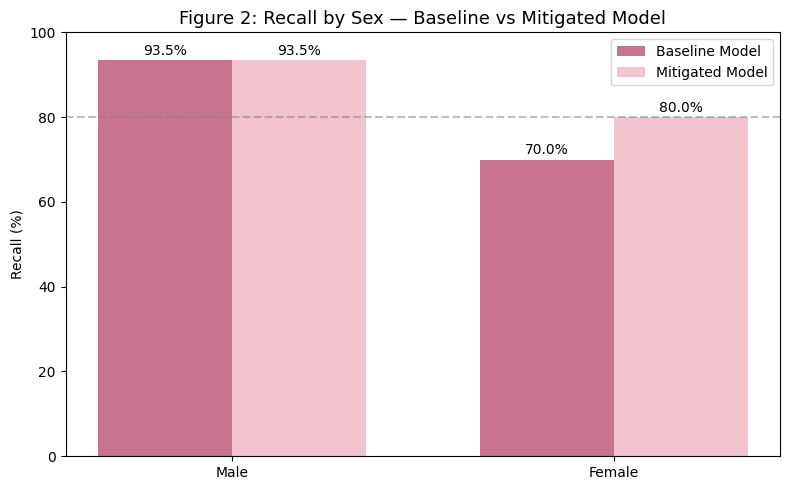

Figure 2 saved — Baseline recall: M=93.5%, F=70.0%
                  Mitigated recall: M=93.5%, F=80.0%


In [41]:

# Compute recall from actual predictions using the shared helper
male_mask = sex_test == 'M'
female_mask = sex_test == 'F'

baseline_recall = [group_metrics(y_test, y_pred, male_mask)[1] * 100,
                   group_metrics(y_test, y_pred, female_mask)[1] * 100]
mitigated_recall = [group_metrics(y_test, y_pred_mitigated, male_mask)[1] * 100,
                    group_metrics(y_test, y_pred_mitigated, female_mask)[1] * 100]

groups = ['Male', 'Female']
x = np.arange(len(groups))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, baseline_recall, width,
               label='Baseline Model', color='#c9748f')
bars2 = ax.bar(x + width/2, mitigated_recall, width,
               label='Mitigated Model', color='#f2c4ce')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_title('Figure 2: Recall by Sex — Baseline vs Mitigated Model', fontsize=13)
ax.set_ylabel('Recall (%)')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylim(0, 100)
ax.legend()
ax.axhline(y=80, color='grey', linestyle='--', alpha=0.5, label='80% threshold')

plt.tight_layout()
plt.savefig('recall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure 2 saved — Baseline recall: M={baseline_recall[0]:.1f}%, F={baseline_recall[1]:.1f}%")
print(f"                  Mitigated recall: M={mitigated_recall[0]:.1f}%, F={mitigated_recall[1]:.1f}%")


## Section 10: Final Leventhal Assessment Summary

This section presents a complete comparison of all six Leventhal rule assessments before and after fairness mitigation. Two criteria pass in both models. Bias suppression shows partial improvement. Three criteria remain unchanged as they require solutions beyond technical pipeline intervention.

In [43]:
print("SECTION 10: FINAL LEVENTHAL ASSESSMENT SUMMARY")
print()
print(f"{'Rule':<20} {'Baseline':<12} {'Mitigated':<12} {'Method':<15}")
print("-" * 65)

summary = {
    "Accuracy"          : ("PASS",    "PASS",    "Quantitative"),
    "Bias Suppression"  : ("FAIL",    "PARTIAL", "Quantitative"),
    "Representativeness": ("FAIL",    "FAIL",    "Quantitative"),
    "Consistency"       : ("FAIL",    "FAIL",    "Quantitative"),
    "Correctability"    : ("FAIL",    "PARTIAL", "Qualitative"),
    "Ethicality"        : ("PASS",    "PASS",    "Qualitative"),
}

for rule, (baseline, mitigated, method) in summary.items():
    print(f"{rule:<20} {baseline:<12} {mitigated:<12} {method:<15}")

print()
print("Bias Suppression: both metrics improved but neither met the ±0.10 threshold")
print(f"  Demographic parity : {dp_diff:.3f} → {dp_diff_mitigated:.3f}")
print(f"  Equalised odds     : {eo_diff:.3f} → {eo_diff_mitigated:.3f}")

print()
print("Key:")
print("  PASS    — criterion met within acceptable threshold")
print("  PARTIAL — criterion still below threshold, but materially improved by mitigation")
print("  FAIL    — criterion not met")
print()
print("Note: Bias suppression improved but remains above the ±0.10 threshold; the small")
print("female test sample (n=39) limits the precision of this estimate. Representativeness")
print("and Consistency require data collection solutions. Correctability requires")
print("institutional design. These are addressed as recommendations in the dissertation.")

SECTION 10: FINAL LEVENTHAL ASSESSMENT SUMMARY

Rule                 Baseline     Mitigated    Method         
-----------------------------------------------------------------
Accuracy             PASS         PASS         Quantitative   
Bias Suppression     FAIL         PARTIAL      Quantitative   
Representativeness   FAIL         FAIL         Quantitative   
Consistency          FAIL         FAIL         Quantitative   
Correctability       FAIL         PARTIAL      Qualitative    
Ethicality           PASS         PASS         Qualitative    

Bias Suppression: both metrics improved but neither met the ±0.10 threshold
  Demographic parity : 0.457 → 0.322
  Equalised odds     : 0.235 → 0.135

Key:
  PASS    — criterion met within acceptable threshold
  PARTIAL — criterion still below threshold, but materially improved by mitigation
  FAIL    — criterion not met

Note: Bias suppression improved but remains above the ±0.10 threshold; the small
female test sample (n=39) limits the pr

In [26]:
print(f"BASELINE  AUROC {auc:.3f}  ACC {overall_accuracy:.3f}")
print(f"  M recall {group_metrics(y_test, y_pred, sex_test=='M')[1]:.3f}  F recall {group_metrics(y_test, y_pred, sex_test=='F')[1]:.3f}")
print(f"  DP {dp_diff:.3f}  EO {eo_diff:.3f}")
print(f"MITIGATED AUROC {auc_mit:.3f}  ACC {overall_accuracy_mit:.3f}")
print(f"  M recall {group_metrics(y_test, y_pred_mitigated, sex_test=='M')[1]:.3f}  F recall {group_metrics(y_test, y_pred_mitigated, sex_test=='F')[1]:.3f}")
print(f"  DP {dp_diff_mitigated:.3f}  EO {eo_diff_mitigated:.3f}")
print(f"INSTABILITY {instability_rate:.1%}")
print(f"FLAGGED {low_conf_count/len(flags)*100:.1f}%")
print(f"REPRESENTATION RATIO {representation_ratio_sex:.2f}")

BASELINE  AUROC 0.957  ACC 0.891
  M recall 0.935  F recall 0.700
  DP 0.457  EO 0.235
MITIGATED AUROC 0.895  ACC 0.880
  M recall 0.935  F recall 0.800
  DP 0.322  EO 0.135
INSTABILITY 9.2%
FLAGGED 10.3%
REPRESENTATION RATIO 0.64


In [27]:
print(list(X.columns))
print("Rows:", len(X), "| Train:", len(X_train), "| Test:", len(X_test))

['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']
Rows: 918 | Train: 734 | Test: 184
